# DAGMC Model Synchronization

This notebook explores a feature of OpenMC that allows for the population of `DAGMCUniverses` with `DAGMCCell` objects that represent the cells generated in DAGMC simulations. These cells reflect the DAGMC model as-interpreted by OpenMC (including adjusted cell and material IDs). And, to an extent, changes to these objects will be reflected in the OpenMC simulatin (i.e. updated material assignments).

This operation uses `Model.sync_dagmc_universes`, which requires that the model be initialized with `Model.init_lib`.

In this notebook, we'll explore the use of this feature for a variety of purposes.

In [1]:
from IPython.display import Image
import openmc
import math
from matplotlib import pyplot as plt

In [2]:
openmc.config['cross_sections'] = '/home/pshriwise/data/xs/openmc/endfb-vii.1-hdf5/cross_sections.xml'

In [3]:
from warnings import warn
import openmc.lib

if not openmc.lib._dagmc_enabled():
    warn("DAGMC is not enabled.")

In [4]:
import urllib.request

fuel_pin_url = 'https://tinyurl.com/y3ugwz6w' # 1.2 MB
teapot_url = 'https://tinyurl.com/y4mcmc3u' # 29 MB
paramak_w_graveyard = 'https://tinyurl.com/y7w238th' # 18 MB

def download(url, filename="dagmc.h5m"):
    """
    Helper function for retrieving dagmc models
    """
    u = urllib.request.urlopen(url)

    if u.status != 200:
        raise RuntimeError("Failed to download file.")

    # save file as dagmc.h5m
    with open(filename, 'wb') as f:
        f.write(u.read())

First, we'll bring in a simple DAGMC model of a fuel pin (see the other notebook on CAD-based geometry for additional information on this model).


In [5]:
download(fuel_pin_url, 'fuel_pin.h5m')

In [6]:
 # materials
u235 = openmc.Material(name="fuel")
u235.add_nuclide('U235', 1.0, 'ao')
u235.set_density('g/cc', 11)
u235.id = 40

water = openmc.Material(name="water")
water.add_nuclide('H1', 2.0, 'ao')
water.add_nuclide('O16', 1.0, 'ao')
water.set_density('g/cc', 1.0)
water.add_s_alpha_beta('c_H_in_H2O')
water.id = 41

materials = openmc.Materials([u235, water])
material_colors = {
    u235: 'green',
    water: 'blue'
}

Now we'll create a DAGMC universe and bound it with CSG reflective planes.

In [7]:
model = openmc.Model()

dag_univ = openmc.DAGMCUniverse(universe_id=5, filename='fuel_pin.h5m')
root_universe = dag_univ.bounded_universe(boundary_type='reflective')

model.geometry = openmc.Geometry(root=root_universe)
model.materials = materials
model.settings.particles = 1000
model.settings.batches = 10
model.settings.inactive = 0


At this point we have model we can run in OpenMC, but some of the functionality available in the Python API for models made entirely from CSG isn't available. For example, only one cell (the bounding cell) is found when calling `get_all_cells` on the geometry.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

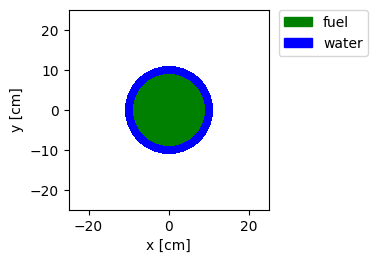

In [8]:
model.plot(color_by='material', colors=material_colors, legend=True)

In [9]:
model.geometry.get_all_cells()


{10000: Cell
 	ID             =	10000
 	Name           =	
 	Fill           =	5
 	Region         =	(10000 -10001 10002 -10003 10004 -10005)
 	Rotation       =	None
 	Translation    =	None
 	Volume         =	None}

Similarly, requesting all material cells returns an empty result, yet we know that material-filled cells must exist in this model.


In [10]:

model.geometry.get_all_material_cells()

{}

In [11]:
dag_univ.get_all_cells()

{}

By initializing the model we can populate additional information on this universe.

In [12]:
model.init_lib()
model.sync_dagmc_universes()
model.finalize_lib()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [13]:
model.geometry.get_all_material_cells()

{np.int32(1): Cell
 	ID             =	1
 	Name           =	
 	Fill           =	Material 40
 	Region         =	None
 	Rotation       =	None
 	Temperature    =	None
 	Translation    =	None
 	Volume         =	None,
 np.int32(2): Cell
 	ID             =	2
 	Name           =	
 	Fill           =	Material 40
 	Region         =	None
 	Rotation       =	None
 	Temperature    =	None
 	Translation    =	None
 	Volume         =	None,
 np.int32(3): Cell
 	ID             =	3
 	Name           =	
 	Fill           =	Material 41
 	Region         =	None
 	Rotation       =	None
 	Temperature    =	None
 	Translation    =	None
 	Volume         =	None}

In [14]:
dag_univ.get_all_cells()

{np.int32(1): Cell
 	ID             =	1
 	Name           =	
 	Fill           =	Material 40
 	Region         =	None
 	Rotation       =	None
 	Temperature    =	None
 	Translation    =	None
 	Volume         =	None,
 np.int32(2): Cell
 	ID             =	2
 	Name           =	
 	Fill           =	Material 40
 	Region         =	None
 	Rotation       =	None
 	Temperature    =	None
 	Translation    =	None
 	Volume         =	None,
 np.int32(3): Cell
 	ID             =	3
 	Name           =	
 	Fill           =	Material 41
 	Region         =	None
 	Rotation       =	None
 	Temperature    =	None
 	Translation    =	None
 	Volume         =	None,
 np.int32(6): Cell
 	ID             =	6
 	Name           =	
 	Fill           =	None
 	Region         =	None
 	Rotation       =	None
 	Translation    =	None
 	Volume         =	None,
 np.int32(7): Cell
 	ID             =	7
 	Name           =	
 	Fill           =	None
 	Region         =	None
 	Rotation       =	None
 	Translation    =	None
 	Volume         =	None}

In addition to being able to view this as-initialized information. The synchonized `DAGMCUniverse` now provides us with some powerful capabilities, like the ability to modify material assignments.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

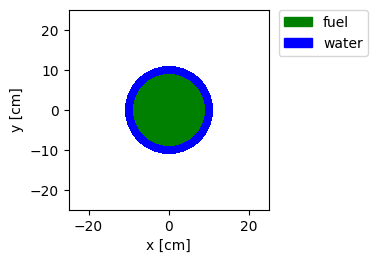

In [15]:

model.plot(color_by='material', colors=material_colors, legend=True)


In [16]:
dag_cells = dag_univ.get_all_cells()
fuel_cell = dag_cells[1]
fuel_cell.fill = water

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

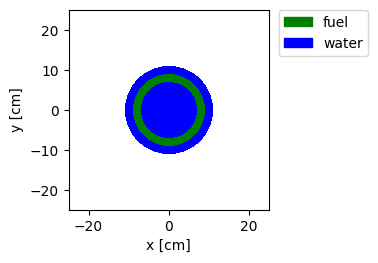

In [17]:
model.plot(color_by='material', colors=material_colors, legend=True)
